# E05 / E02-long — concept-bottleneck text generation

Generate text from three `concept_ar` checkpoints and compare them side by side.

| label | optimizer | data | epochs | decoder | eval signal |
|---|---|---|---|---|---|
| **E02-long** | AdamW | FineWeb-Edu sample-10BT | 5 | full-causal (K=None) | suffix-CE 3.18, **STS-B 0.714** |
| **E05 Adam** | AdamW | smollm3_inspired_2k (small mix) | 0.5 | windowed K=128 | eval_loss 3.83 |
| **E05 Muon** | Muon | smollm3_inspired_2k (small mix) | 0.5 | windowed K=128 | eval_loss 2.61 |

## How generation works here (read this first)

This is **not** a normal causal LM. It is the project's **encode -> reason -> decode**
architecture (`ConceptEncoderForConditionalLM`):

1. Your prompt is encoded by the encoder into **C = 128 latent concept vectors**.
2. The decoder then free-decodes a fresh sequence from the BOS token, **cross-attending
   only to those 128 concepts** plus its own recent tokens (last K=128 on E05, all tokens
   on E02-long).

So the decoder **never sees your prompt's exact tokens** — only their compression into
128 concepts. The output is a function of the prompt's *meaning*, not its wording, and it
is a fresh generation from BOS rather than a token-level continuation. Think of it as
'what does the model understand from this prompt, routed through 128 concepts'.

Consequences:
- These are **base concept-LMs, not instruction-tuned**. Use continuation-style prompts
  ('The future of ...'), not instructions ('Write a poem about ...').
- The HF API is used for loading (`from_pretrained`, `AutoTokenizer`) and the decode loop,
  but the model does **not** implement `GenerationMixin`, so the autoregressive step is a
  custom loop (greedy / temperature + top-k + top-p sampling over `encode_concepts` ->
  `decode_logits`) — mirroring `analysis/run_concept_analysis.py:generate_ar_samples`.
- **No KV cache**: each step reruns the decoder over the whole sequence, so keep
  `max_new_tokens` at or below ~200 for snappy interaction.
- Expected ordering: **E02-long should be far more coherent** (strong concepts, STS-B
  0.714); the two E05 0.5-ep models are weaker (the run report flags 'repetition loops').
  The Adam-vs-Muon gap is an *optimization-speed* difference (Muon eval_loss 2.61 vs
  Adam 3.83 at equal tokens), which may or may not surface as a generation-quality gap.


In [2]:
import os, sys, time
from pathlib import Path

# repo root -- edit only if you moved the checkout
REPO = '/Users/ksirg/devel/MrCogito'
if not Path(REPO, 'nn').is_dir():
    REPO = os.getcwd()                      # fallback: launched from repo root
sys.path.insert(0, REPO)

import torch
from transformers import AutoTokenizer
from nn.concept_encoder_perceiver import ConceptEncoderForConditionalLM

DEVICE = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print('repo:  ', REPO)
print('device:', DEVICE, '| torch', torch.__version__)


repo:   /Users/ksirg/devel/MrCogito
device: mps | torch 2.11.0


In [3]:
CKPT_ROOT = Path(REPO, 'Cache/Training')

# label -> checkpoint metadata
CHECKPOINTS = {
    'E02-long (5ep fineweb)': dict(
        path=CKPT_ROOT / 'concept_ar_prefix_H768L6C128D4_20260614_101305' / 'checkpoint-296000',
        optimizer='adamw', epochs=5, dataset='FineWeb-Edu sample-10BT',
        window='full-causal (K=None)', eval_loss='suffix-CE 3.181',
        note='semantic leader (STS-B 0.714, RankMe 246)'),
    'E05 Adam (0.5ep small mix)': dict(
        path=CKPT_ROOT / 'concept_ar_prefix_H768L6C128D4_20260629_093840' / 'checkpoint-69142',
        optimizer='adamw', epochs=0.5, dataset='smollm3_inspired_2k_e05',
        window='windowed K=128', eval_loss='3.829',
        note='E05 attempt-3 (stable recipe)'),
    'E05 Muon (0.5ep small mix)': dict(
        path=CKPT_ROOT / 'concept_ar_prefix_H768L6C128D4_20260702_031956' / 'checkpoint-69142',
        optimizer='muon', epochs=0.5, dataset='smollm3_inspired_2k_e05',
        window='windowed K=128', eval_loss='2.606',
        note='Muon A/B retry (wd0.1, adamw_lr2e-4)'),
}

for label, info in CHECKPOINTS.items():
    p = info['path']
    ok = p.is_dir() and (p / 'model.safetensors').exists()
    tag = 'OK' if ok else 'MISSING -- download still running?'
    print(f'[{tag}] {label}')
    print(f'        {p}')


[OK] E02-long (5ep fineweb)
        /Users/ksirg/devel/MrCogito/Cache/Training/concept_ar_prefix_H768L6C128D4_20260614_101305/checkpoint-296000
[OK] E05 Adam (0.5ep small mix)
        /Users/ksirg/devel/MrCogito/Cache/Training/concept_ar_prefix_H768L6C128D4_20260629_093840/checkpoint-69142
[OK] E05 Muon (0.5ep small mix)
        /Users/ksirg/devel/MrCogito/Cache/Training/concept_ar_prefix_H768L6C128D4_20260702_031956/checkpoint-69142


## Load the three checkpoints

Each is ~620 MB of weights (optimizer state was excluded from the download). All three
stay resident so the cells below are instant; call `unload()` to free memory.

In [4]:
MODELS = {}
for label, info in CHECKPOINTS.items():
    p = info['path']
    if not p.is_dir():
        print(f'skip {label}: not found at {p}')
        continue
    t0 = time.time()
    model = ConceptEncoderForConditionalLM.from_pretrained(p).to(DEVICE).eval()
    tok = AutoTokenizer.from_pretrained(p)
    MODELS[label] = dict(model=model, tokenizer=tok, info=info)
    n = sum(x.numel() for x in model.parameters())
    print(f"loaded {label}: {n/1e6:.1f}M params, K={model.config.decoder_context_window}, {time.time()-t0:.1f}s")
print('\nready:', list(MODELS))


loaded E02-long (5ep fineweb): 161.6M params, K=None, 0.3s
loaded E05 Adam (0.5ep small mix): 162.0M params, K=128, 0.3s
loaded E05 Muon (0.5ep small mix): 162.0M params, K=128, 0.3s

ready: ['E02-long (5ep fineweb)', 'E05 Adam (0.5ep small mix)', 'E05 Muon (0.5ep small mix)']


In [5]:
def unload(label=None):
    'Free a model (or all of them) from memory.'
    import gc
    for t in ([label] if label else list(MODELS)):
        m = MODELS.pop(t, None)
        if m is None:
            continue
        del m
        gc.collect()
        try:
            torch.mps.empty_cache()
        except Exception:
            pass
        print('unloaded', t)


## Generation primitive

`generate(label, prompt, ...)` -> decoded text. `generate_all(prompt, ...)` runs every
loaded model and returns a `{label: text}` dict. Pass `greedy=True` for a deterministic,
reproducible comparison across models.

In [6]:
@torch.no_grad()
def generate(label, prompt, max_new_tokens=128, temperature=0.9, top_k=50,
             top_p=0.95, greedy=False, seed=None, max_prompt_len=2048):
    '''Encode `prompt` into C=128 concepts, then free-decode a continuation from BOS.

    Concept-bottleneck decode: the decoder sees only the 128 concepts (not the prompt
    tokens) plus its own recent output. greedy=True -> argmax; otherwise temperature +
    top-k + top-p sampling. seed makes sampling reproducible.
    '''
    m = MODELS[label]
    model, tokenizer = m['model'], m['tokenizer']
    cfg = model.config
    start_id = cfg.bos_token_id or cfg.eos_token_id or cfg.pad_token_id or 0
    eos_id = cfg.eos_token_id
    if seed is not None:
        torch.manual_seed(int(seed))

    enc = tokenizer(prompt, truncation=True, max_length=max_prompt_len, return_tensors='pt')
    input_ids = enc['input_ids'].to(DEVICE)
    attn = torch.ones_like(input_ids)
    concepts = model.encode_concepts(input_ids=input_ids, attention_mask=attn,
                                     return_dict=True).last_hidden_state   # [1, C, H]

    cur = torch.tensor([[start_id]], device=DEVICE, dtype=torch.long)
    for _ in range(max_new_tokens):
        logits = model.decode_logits(concepts, cur)[:, -1, :]             # [1, V]
        if greedy or not temperature or temperature <= 0:
            nxt = logits.argmax(dim=-1, keepdim=True)
        else:
            logits = logits / temperature
            if top_k and top_k > 0:                                       # top-k
                k = min(int(top_k), logits.size(-1))
                thresh = torch.topk(logits, k).values[:, -1:]
                logits[logits < thresh] = float('-inf')
            if top_p and 0 < top_p < 1.0:                                 # nucleus
                sl, si = torch.sort(logits, descending=True)
                sprobs = torch.softmax(sl, dim=-1)
                remove = (sprobs.cumsum(dim=-1) - sprobs) >= top_p
                sl[remove] = float('-inf')
                logits = logits.scatter(-1, si, sl)
            nxt = torch.multinomial(torch.softmax(logits, dim=-1), num_samples=1)
        cur = torch.cat([cur, nxt], dim=1)
        if eos_id is not None and nxt.item() == eos_id:
            break
    return tokenizer.decode(cur[0, 1:].tolist(), skip_special_tokens=True).strip()


def generate_all(prompt, **kw):
    return {label: generate(label, prompt, **kw) for label in MODELS}


## Single prompt, all three models

Edit `PROMPT` and re-run. Use `greedy=True` for a deterministic comparison.

In [7]:
PROMPT = 'The future of renewable energy depends on'

print('PROMPT:', PROMPT)
print('=' * 90)
for label in MODELS:
    out = generate(label, PROMPT, max_new_tokens=100, temperature=0.9, top_k=50, top_p=0.95, seed=0)
    print(f'\n--- {label} ---\n{out}\n')


PROMPT: The future of renewable energy depends on

--- E02-long (5ep fineweb) ---
- Renewable energy:
- Energy from renewable sources:
- Renewable energy:
- Solar energy:
- Renewable energy:
- Renewable energy:
- Wind energy:
- Biofuels:
- Water:
- Wind energy:
- Wind energy:
- Energy from renewables:
- Biomass:
- Coal:
- Biomass:
- Hydro:
- Wind energy:
- Wind energy:
- Solar energy:
- Wind energy:


--- E05 Adam (0.5ep small mix) ---
- State of Energy
- Energy, Engineering 2023, UK 4026, December 2020, June 2020, December 4300, November 2022, September 2022, June 2020, March 20, September 2023, July 2021, June 2022, November 2020, August


--- E05 Muon (0.5ep small mix) ---
The energy of electric vehicles is based on the energy of the sun and the energy of fusion processes is based on the amount of energy transferred by the solar system or on the number of years of waste generation in the system.

The energy of solar plants in the US is expected to be between 2007 and 2012, which are

## Prompt battery

The same set of continuation prompts through all three models.

In [8]:
PROMPTS = [
    'The future of renewable energy depends on',
    'Once upon a time, in a quiet village',
    'The most important skill in software engineering is',
    'Scientists have long wondered whether',
    'In machine learning, a gradient is',
]

for prompt in PROMPTS:
    outs = generate_all(prompt, max_new_tokens=80, temperature=0.9, top_k=50, top_p=0.95, seed=0)
    print('Q:', prompt)
    for label in MODELS:
        print(f'  [{label}]: {outs[label]}')
    print()


Q: The future of renewable energy depends on
  [E02-long (5ep fineweb)]: - Renewable energy:
- Energy from renewable sources:
- Renewable energy:
- Solar energy:
- Renewable energy:
- Renewable energy:
- Wind energy:
- Biofuels:
- Water:
- Wind energy:
- Wind energy:
- Energy from renewables:
- Biomass:
- Coal:
- Biomass:
- Hydro:
  [E05 Adam (0.5ep small mix)]: - State of Energy
- Energy, Engineering 2023, UK 4026, December 2020, June 2020, December 4300, November 2022, September 2022, June 2020, March 20, September 2023, July 2
  [E05 Muon (0.5ep small mix)]: The energy of electric vehicles is based on the energy of the sun and the energy of fusion processes is based on the amount of energy transferred by the solar system or on the number of years of waste generation in the system.

The energy of solar plants in the US is expected to be between 2007 and 2012, which are the most economically important times

Q: Once upon a time, in a quiet village
  [E02-long (5ep fineweb)]: It is a t

## Your own prompt

Edit `PROMPT` and `GEN_KW`, re-run.

In [9]:
PROMPT = 'The meaning of life is'
GEN_KW = dict(max_new_tokens=120, temperature=0.8, top_k=40, top_p=0.9, seed=0)
# GEN_KW = dict(max_new_tokens=120, greedy=True)   # deterministic compare

print('PROMPT:', PROMPT)
print('=' * 90)
for label in MODELS:
    out = generate(label, PROMPT, **GEN_KW)
    print(f'\n--- {label} ---\n{out}\n')


PROMPT: The meaning of life is

--- E02-long (5ep fineweb) ---
It is a term of the 10000s that was used by the British Government in the 1840s to refer to the British Parliament. The word was first used in the 1850s to refer to the United Kingdom.
In the 1860s, the British Parliament passed a law, called the Free Trade Act, which prohibited the slave trade.
The term was first used in the 1870s to refer to the United Kingdom’s free trade, which was the British Parliament, in the 18


--- E05 Adam (0.5ep small mix) ---
- History of the United Kingdom
- Bible with the Old Testament
- God the Christian and the King
- Father
- God


--- E05 Muon (0.5ep small mix) ---
The last thing I know about this world is the last thing I know about this world.



## Reading the comparison

- **Coherence axis (data scale):** E02-long (5 ep FineWeb) vs the two 0.5-ep E05 models.
  If the concepts carry meaning, E02-long's generations should be visibly more fluent and
  on-topic.
- **Optimizer axis (Adam vs Muon):** both at 0.5 ep / step 69142 on the same small mix.
  Muon reached a much lower eval_loss (2.61 vs 3.83) in the same tokens — does that mean
  better generation, or did it optimize a different (non-semantic) surface? Compare
  repetition, topical relevance, and lexical diversity.
- **Window axis:** E05 is windowed (decoder sees only its last 128 generated tokens);
  E02-long is full-causal. This matters most on longer generations.

If a model collapses to a repetition loop, lower `temperature`, raise `top_k`, shorten
`max_new_tokens`, or switch to `greedy=True`. For a clean across-model compare, fix a
`seed` or use greedy.


## Realistic regime: ~1K-token prompt -> ~1K-token answer

The default prompts above are 5-10 tokens — a degenerate regime for this architecture
(it is designed for 4:1-128:1 *compression*, not 0.08:1 expansion). The loopiness
visible there conflates three failure sources:
- **(a) regime mismatch** (encoding 7 tokens into 128 concepts is an expansion, not compression),
- **(b) base-model quality** (162M params, 0.5-5 ep — vanilla causal LMs at this scale also loop),
- **(c) the architectural self-context gap** (the E09 question: frozen concept snapshot + K-window).

The realistic regime below isolates **(a)**: a ~1K-token prompt (matching E05's seq-2048
training) -> ~1K-token free generation, where the 128 concepts are genuinely lossy
compression. We pull one long document from FineWeb-Edu (E02-long's training data) so
every model sees the same long context, then summarize each generation with the
project's diversity metrics (`evaluation.generation_quality.summarize_generation`).

**How to read it.** distinct-1 ≈ 1.0 / rep-1 ≈ 0.0 means diverse generation;
distinct-1 < 0.2 / rep-1 > 0.8 is a repetition loop. Watch how the diversity changes
as generated length exceeds the decoder's K window (E05: 128; E02-long: no window) —
the per-bin distinct-1 in the length-binned diversity profile is the E09 Stage-0
diagnostic in miniature.

In [10]:
from datasets import load_dataset
from evaluation.generation_quality import summarize_generation

# Pull one ~1K-token document from FineWeb-Edu (E02-long's training data).
# Streaming -> no download; we walk forward until we find a doc long enough.

TARGET_PROMPT_TOKENS = 1024
GEN_MAX_NEW = 1024

ds = load_dataset('HuggingFaceFW/fineweb-edu', 'sample-10BT', split='train', streaming=True)
long_doc = None
for sample in ds:
    text = sample.get('text', '') or ''
    n_tok = len(MODELS[list(MODELS)[0]]['tokenizer'](text, truncation=False)['input_ids'])
    if n_tok >= TARGET_PROMPT_TOKENS:
        long_doc = text
        long_doc_n_tok = n_tok
        break
print(f'Picked a FineWeb-Edu doc: {long_doc_n_tok} tokens (target was >= {TARGET_PROMPT_TOKENS}).')
print('First 300 chars:', ' '.join(long_doc[:300].split()))

README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/2410 [00:00<?, ?it/s]

Picked a FineWeb-Edu doc: 1067 tokens (target was >= 1024).
First 300 chars: Taking Play Seriously By ROBIN MARANTZ HENIG Published: February 17, 2008 On a drizzly Tuesday night in late January, 200 people came out to hear a psychiatrist talk rhapsodically about play -- not just the intense, joyous play of children, but play for all people, at all ages, at all times. (All sp


In [11]:
# Free-decode ~1K tokens from each model on the same long prompt.
# Greedy -> reproducible across models (the only fair across-model compare at this scale).
# No KV cache -> each step reruns the decoder; 1024 new tokens takes ~1-2 min per model on MPS.
realistic_outputs = {}
for label in MODELS:
    out = generate(label, long_doc, max_new_tokens=GEN_MAX_NEW, greedy=True)
    realistic_outputs[label] = out
    print(f'--- {label}: generated {len(out.split())} words ---')
    print(out[:500].replace('\n', ' '))
    print('...')
    print()

--- E02-long (5ep fineweb): generated 248 words ---
"I think it's important to understand that play is a very important part of human development," Brown said. "It's important to understand that play is a very important part of human development." The study, published in the journal Developmental and Brain Sciences, found that children who played with a computer or video game were more likely to have a higher IQ than those who played with a computer or video game. "We know that children who play with computers and video games are more likely to h
...

--- E05 Adam (0.5ep small mix): generated 836 words ---
The first step is to be a good idea of the world's life. The second step is to be a good idea of the world's life. The second step is to be a good idea of the world's life. The second step is to be a good idea of the world's life. The second step is to be a good idea of the world's life. The second step is to be a good idea of the world's life. The second step is to be a good idea of

In [12]:
# Diversity summary with the project's metrics. Each row is one model.
# Set decoder_window_k to match each model's window (E05: 128; E02-long: 128 here as
# a uniform bin size — E02-long is full-causal, so its 'window' is only for display).
rows = []
for label, out in realistic_outputs.items():
    info = MODELS[label]['info']
    ids = MODELS[label]['tokenizer'](out, add_special_tokens=False)['input_ids']
    summary = summarize_generation(ids, decoder_window_k=128)
    rows.append({
        'label': label,
        'n_gen_tokens': summary['n_tokens'],
        'distinct_1': round(summary['distinct_1'], 3),
        'distinct_2': round(summary['distinct_2'], 3),
        'rep_1': round(summary['repetition_1'], 3),
        'rep_3': round(summary['rep_3'], 3),
        'window': info['window'],
    })

import pandas as pd
df = pd.DataFrame(rows)
df

,label,n_gen_tokens,distinct_1,distinct_2,rep_1,rep_3,window
0,E02-long (5ep fineweb),278,0.209,0.289,0.791,0.629,full-causal (K=None)
1,E05 Adam (0.5ep small mix),1023,0.018,0.020,0.982,0.978,windowed K=128
2,E05 Muon (0.5ep small mix),1023,0.020,0.025,0.980,0.972,windowed K=128


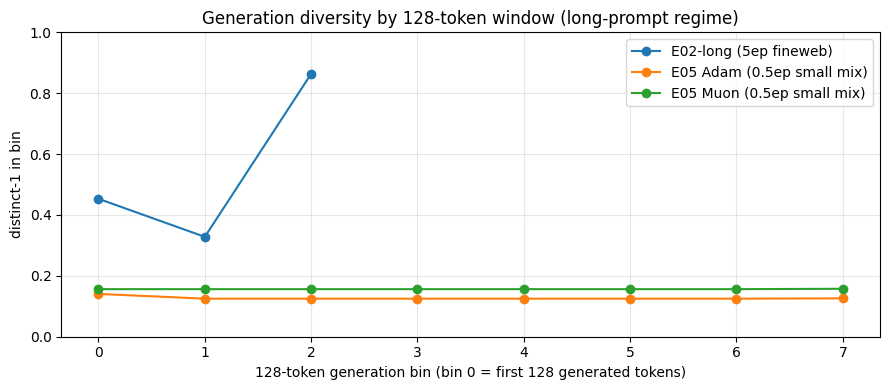

In [13]:
# Per-bin distinct-1 across 128-token windows of each generation.
# A profile that falls toward the end is the repetition-loop signature (E09 Stage-0
# in miniature — diversity collapsing once generation exceeds local context reach).
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 4))
for label, out in realistic_outputs.items():
    ids = MODELS[label]['tokenizer'](out, add_special_tokens=False)['input_ids']
    prof = summarize_generation(ids, decoder_window_k=128)['length_binned_diversity']
    bin_idx = [b['bin_index'] for b in prof['bins']]
    bin_d1 = [b['distinct_n_by_n'][1] for b in prof['bins']]
    ax.plot(bin_idx, bin_d1, marker='o', label=label)

ax.set_xlabel('128-token generation bin (bin 0 = first 128 generated tokens)')
ax.set_ylabel('distinct-1 in bin')
ax.set_title('Generation diversity by 128-token window (long-prompt regime)')
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()